# Model Training

In [2]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
# Modelling
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

In [3]:
df = pd.read_csv('data/StudentsPerformance.csv')

##### Show top 5 records

In [4]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


##### Preparing X and y variables

In [5]:
X = df.drop('math score',axis = 1)
y = df['math score']

In [6]:
X.shape

(1000, 7)

In [7]:
y.shape

(1000,)

##### Standardizing and encoding

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
numeric_col = [i for i in df.columns if df[i].dtype !='O']
categorical_col = [i for i in df.columns if df[i].dtype =='O']

preprocessor = ColumnTransformer([
    ("standard_scaler", StandardScaler(), numeric_col),
            ("OneHotEncoder", OneHotEncoder(), categorical_col)
])

In [9]:
numeric_col.remove("math score")

In [10]:
numeric_col

['reading score', 'writing score']

##### Splitting the dataset into training and testing datasets 

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [12]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

##### Writing a function to evaluate the model 

In [13]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [14]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}
model_list=[]
r2_scores = []
for name,model in models.items():
    model.fit(X_train,y_train)
    test_pred = model.predict(X_test) 
    train_pred = model.predict(X_train)
    testing_mae, testing_rmse, testing_r2_square = evaluate_model(y_test, test_pred)
    training_mae, training_rmse, training_r2_square = evaluate_model(y_train, train_pred)
    r2_scores.append(testing_r2_square)
    model_list.append(name)
    print("---------------------------------------"+name+"---------------------------------------")
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(training_rmse))
    print("- Mean Absolute Error: {:.4f}".format(training_mae))
    print("- R2 Score: {:.4f}".format(training_r2_square))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(testing_rmse))
    print("- Mean Absolute Error: {:.4f}".format(testing_mae))
    print("- R2 Score: {:.4f}".format(testing_r2_square))
    r2_scores.append(testing_r2_square)
    
    print('='*35)
    print('\n')

---------------------------------------Linear Regression---------------------------------------
Model performance for Training set
- Root Mean Squared Error: 5.3231
- Mean Absolute Error: 4.2667
- R2 Score: 0.8743
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.3940
- Mean Absolute Error: 4.2148
- R2 Score: 0.8804


---------------------------------------Lasso---------------------------------------
Model performance for Training set
- Root Mean Squared Error: 6.5925
- Mean Absolute Error: 5.2053
- R2 Score: 0.8072
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 6.5173
- Mean Absolute Error: 5.1557
- R2 Score: 0.8254


---------------------------------------Ridge---------------------------------------
Model performance for Training set
- Root Mean Squared Error: 5.3233
- Mean Absolute Error: 4.2650
- R2 Score: 0.8743
----------------------------------
Model performance for Test set
- Root Mean Sq

##### Results

In [15]:
pd.DataFrame(list(zip(model_list,r2_scores)),columns=["models","r2_scores"]).sort_values("r2_scores",ascending=False)

,models,r2_scores
4,Decision Tree,0.880592
5,Random Forest Regressor,0.880592
0,Linear Regression,0.880433
1,Lasso,0.880433
2,Ridge,0.825447
3,K-Neighbors Regressor,0.825447
6,XGBRegressor,0.783482
7,CatBoosting Regressor,0.783482
8,AdaBoost Regressor,0.732410


## Linear Regression

In [17]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test, y_pred)*100
print(" Accuracy of the model is %.2f" %score)

 Accuracy of the model is 88.04


## Plot y_pred and y_test

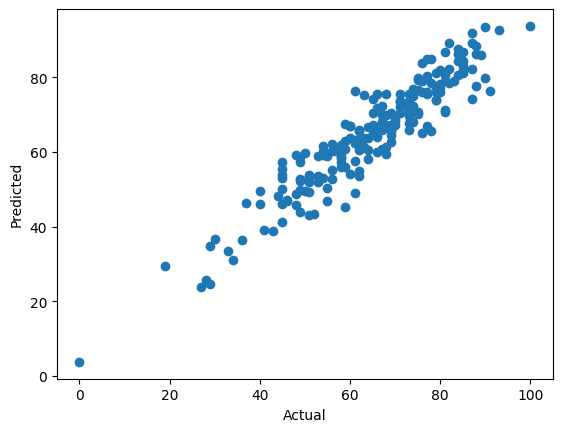

In [18]:
plt.scatter(y_test,y_pred);
plt.xlabel('Actual');
plt.ylabel('Predicted');

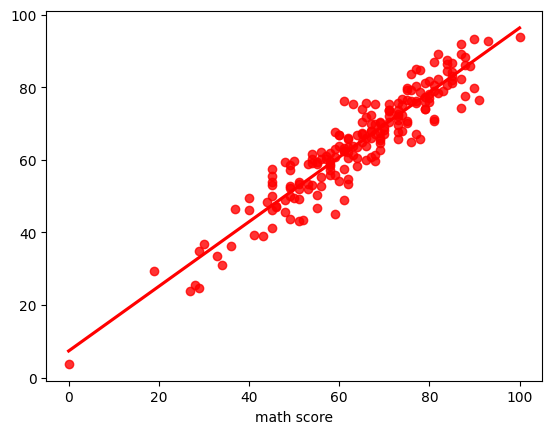

In [19]:
sns.regplot(x=y_test,y=y_pred,ci=None,color ='red');

#### Difference between Actual and Predicted Values

In [20]:
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
